In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,precision_score,recall_score, log_loss,f1_score, accuracy_score
import time
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB


In [2]:
df = pd.read_csv('smart_grid_stability_augmented.csv')
df.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


## Checking for null values

In [3]:
print(df.isnull().sum())

tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64


# Encoding target variable

In [4]:
label_encoder = LabelEncoder()
df['stabf'] = label_encoder.fit_transform(df['stabf'])

## Finding correlation


In [5]:
df.corr()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
tau1,1.000000,-0.002550,-0.002550,-0.002550,0.027183,-0.015739,-0.015739,-0.015739,0.010521,0.006522,0.006522,0.006522,0.275761,0.234898
tau2,-0.002550,1.000000,0.005554,0.005554,0.003004,-0.004473,-0.000372,-0.000372,-0.005832,0.009865,0.002102,0.002102,0.283417,0.241049
tau3,-0.002550,0.005554,1.000000,0.005554,0.003004,-0.000372,-0.004473,-0.000372,-0.005832,0.002102,0.009865,0.002102,0.283417,0.241049
tau4,-0.002550,0.005554,0.005554,1.000000,0.003004,-0.000372,-0.000372,-0.004473,-0.005832,0.002102,0.002102,0.009865,0.283417,0.241049
p1,0.027183,0.003004,0.003004,0.003004,1.000000,-0.578983,-0.578983,-0.578983,0.000721,0.000341,0.000341,0.000341,0.010278,0.009938
p2,-0.015739,-0.004473,-0.000372,-0.000372,-0.578983,1.000000,0.002833,0.002833,-0.000417,-0.002141,0.000774,0.000774,-0.005951,-0.005754
p3,-0.015739,-0.000372,-0.004473,-0.000372,-0.578983,0.002833,1.000000,0.002833,-0.000417,0.000774,-0.002141,0.000774,-0.005951,-0.005754
p4,-0.015739,-0.000372,-0.000372,-0.004473,-0.578983,0.002833,0.002833,1.000000,-0.000417,0.000774,0.000774,-0.002141,-0.005951,-0.005754
g1,0.010521,-0.005832,-0.005832,-0.005832,0.000721,-0.000417,-0.000417,-0.000417,1.000000,0.004718,0.004718,0.004718,0.282774,0.197664
g2,0.006522,0.009865,0.002102,0.002102,0.000341,-0.002141,0.000774,0.000774,0.004718,1.000000,-0.006939,-0.006939,0.293684,0.218015


## Exploring data distribution 

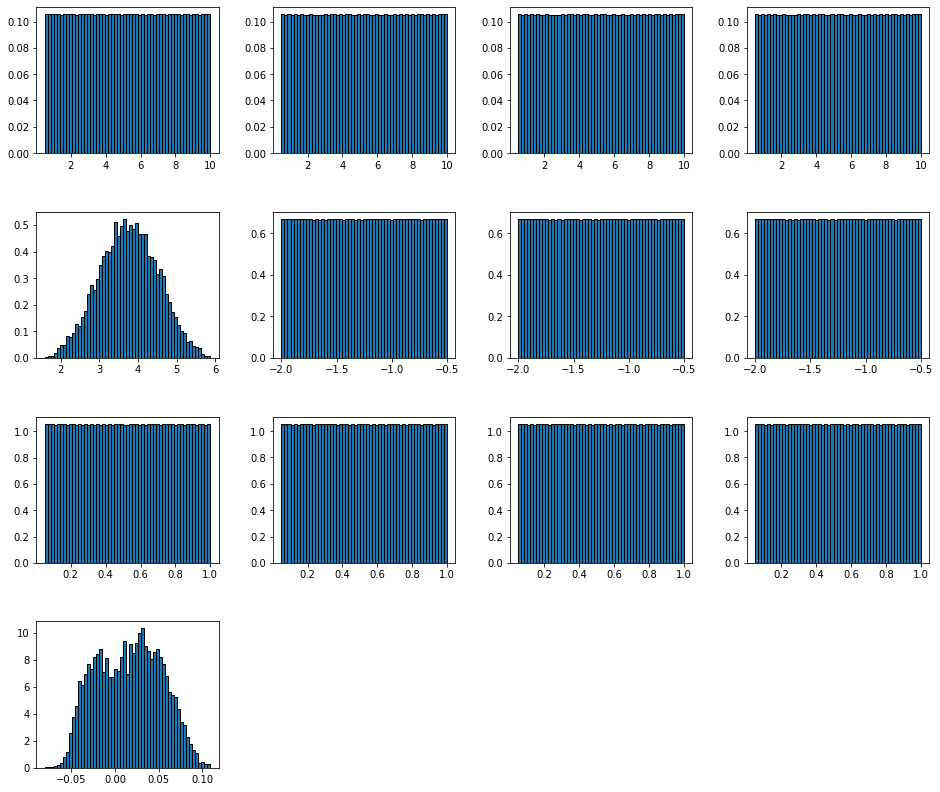

In [6]:
fig, axs = plt.subplots(4, 4, figsize=(16, 14))
axs[0,0].hist(df['tau1'], bins=55, ec='black', density=True)
axs[0,1].hist(df['tau2'], bins=55, ec='black', density=True)
axs[0,2].hist(df['tau3'], bins=55, ec='black', density=True)
axs[0,3].hist(df['tau4'], bins=55, ec='black', density=True)
axs[1,0].hist(df['p1'], bins=55, ec='black', density=True)
axs[1,1].hist(df['p2'], bins=55, ec='black', density=True)
axs[1,2].hist(df['p3'], bins=55, ec='black', density=True)
axs[1,3].hist(df['p4'], bins=55, ec='black', density=True)
axs[2,0].hist(df['g1'], bins=55, ec='black', density=True)
axs[2,1].hist(df['g2'], bins=55, ec='black', density=True)
axs[2,2].hist(df['g3'], bins=55, ec='black', density=True)
axs[2,3].hist(df['g4'], bins=55, ec='black', density=True)
axs[3,0].hist(df['stab'], bins=55, ec='black', density=True)
axs[3,1].remove()
axs[3,2].remove()
axs[3,3].remove()
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()


# Feature Scaling 

In [7]:
scaler = StandardScaler()
df.iloc[:, :-1] = scaler.fit_transform(df.iloc[:, :-1])
df.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,-0.835374,-0.791316,1.141704,1.652104,0.017397,1.079404,-0.017078,-1.092544,0.457467,1.220013,1.321628,1.579026,1.073120,1
1,1.478297,-0.126705,-0.803110,-1.415046,1.752124,-1.593619,-1.438158,-0.011575,-0.406791,1.230355,0.135424,0.936255,-0.587487,0
2,1.357093,1.312139,-0.803497,-1.471507,-0.458492,0.098252,-0.062839,0.760964,-1.319852,0.881299,1.146596,-1.513803,-0.332095,1
3,-1.653138,0.882288,-0.278353,-1.060904,0.284250,0.513903,-1.591046,0.583415,-0.287304,1.647250,1.474543,-0.591751,0.355922,1
4,-0.771543,0.860108,-0.111668,1.680116,-0.298075,0.287448,-1.376343,1.606636,0.992226,-0.253610,0.481133,1.079062,0.924487,1


## Splitting Training and Testing Data

In [8]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df.iloc[:, -1], test_size=0.2, random_state=42)
X_train.drop(['p1'], axis=1, inplace=True)
X_test.drop(['p1'], axis=1, inplace=True)

In [9]:
X_test.shape

y_test.sum()


7678

## Model Application: Random Forest

In [10]:
model1=RandomForestClassifier()
start_time = time.time()
model1.fit(X_train, y_train)
end_time = time.time()
running_time = end_time - start_time
ypred=model1.predict(X_test)
print('training time:', round(running_time,4))
print('accuracy',accuracy_score(y_test, ypred))
print('recall', recall_score(y_test, ypred))
print('log loss',log_loss(y_test, ypred))
print('precision',precision_score(y_test, ypred))
print('f1score',f1_score(y_test, ypred))
cm_RF=confusion_matrix(y_test, ypred)
print('confusion matrix', cm_RF)


training time: 7.1694
accuracy 1.0
recall 1.0
log loss 9.992007221626413e-16
precision 1.0
f1score 1.0
confusion matrix [[4322    0]
 [   0 7678]]


### Model Application: Logistic Regression

In [11]:
model2=LogisticRegression()
start_time = time.time()
model2.fit(X_train, y_train)
end_time = time.time()
running_time = end_time - start_time
ypred2=model2.predict(X_test)
print('training time:', round(running_time,4))
print('accuracy',accuracy_score(y_test, ypred2))
print('recall', recall_score(y_test, ypred2))
print('precision',precision_score(y_test, ypred2))
print('f1score',f1_score(y_test, ypred2))
print('log loss',log_loss(y_test, ypred2))
cm_LR=confusion_matrix(y_test, ypred2)
print('confusion matrix\n', cm_LR)


training time: 0.1846
accuracy 0.9995
recall 0.9996092732482418
precision 0.9996092732482418
f1score 0.9996092732482418
log loss 0.01726958809681389
confusion matrix
 [[4319    3]
 [   3 7675]]


## Model Application: KNN

In [12]:
knn=KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='uniform')
start_time = time.time()
knn.fit(X_train, y_train)
end_time = time.time()
running_time = end_time - start_time
ypred3=knn.predict(X_test)
print('training time:', round(running_time,4))
print('accuracy',accuracy_score(y_test, ypred3))
print('recall', recall_score(y_test, ypred3))
print('precision',precision_score(y_test, ypred3))
print('f1score',f1_score(y_test, ypred3))
print('log loss',log_loss(y_test, ypred3))
cm_knn=confusion_matrix(y_test, ypred3)
print('confusion matrix\n', cm_knn)

training time: 0.3354
accuracy 0.9549166666666666
recall 0.9708257358687158
precision 0.9592073092266118
f1score 0.9649815522040261
log loss 1.557144291836005
confusion matrix
 [[4005  317]
 [ 224 7454]]


## Model Application: Naive Bayes

In [13]:
Nb = GaussianNB()
start_time = time.time()
Nb.fit(X_train, y_train)
end_time = time.time()
running_time = end_time - start_time
ypred4=Nb.predict(X_test)
print('training time:', round(running_time,4))
print('accuracy',accuracy_score(y_test, ypred4))
print('recall', recall_score(y_test, ypred4))
print('precision',precision_score(y_test, ypred4))
print('f1score',f1_score(y_test, ypred4))
print('log loss',log_loss(y_test, ypred4))
cm_nb=confusion_matrix(y_test, ypred4)
print('confusion matrix\n', cm_nb)

training time: 0.04
accuracy 0.9805833333333334
recall 0.979812451159156
precision 0.9897381923431128
f1score 0.9847503108842203
log loss 0.6706331057178129
confusion matrix
 [[4244   78]
 [ 155 7523]]


# Plotting FNs and FPs to evaluate model performance

Text(0.5, 1.0, 'False Positives and False Negatives of RandomForest')

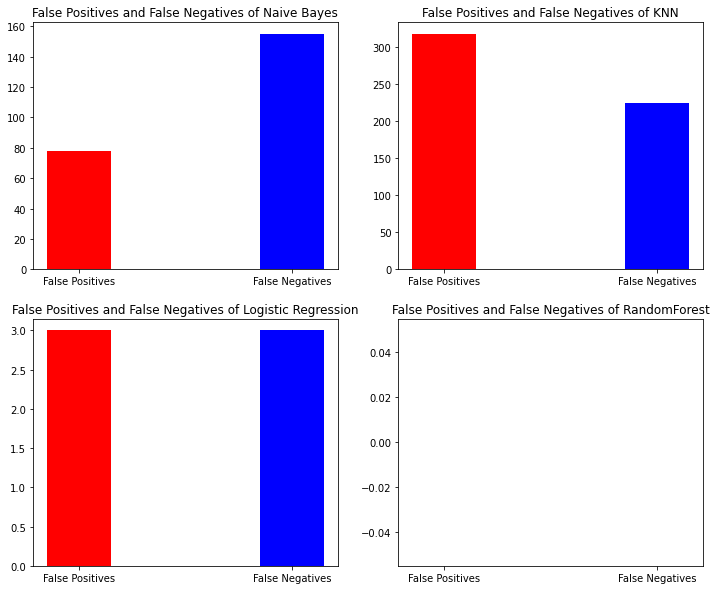

In [14]:
fig, axse = plt.subplots(2, 2, figsize=(12, 10))

axse[0,0].bar(['False Positives', 'False Negatives'], [cm_nb[0,1], cm_nb[1,0]], color=['red', 'blue'], width=0.3)
axse[0,0].set_title('False Positives and False Negatives of Naive Bayes')

axse[0,1].bar(['False Positives', 'False Negatives'], [cm_knn[0,1], cm_knn[1,0]], color=['red', 'blue'], width=0.3)
axse[0,1].set_title('False Positives and False Negatives of KNN')

axse[1,0].bar(['False Positives', 'False Negatives'], [cm_LR[0,1], cm_LR[1,0]], color=['red', 'blue'], width=0.3)
axse[1,0].set_title('False Positives and False Negatives of Logistic Regression')


axse[1,1].bar(['False Positives', 'False Negatives'], [cm_RF[0,1], cm_RF[1,0]], color=['red', 'blue'], width=0.3)
axse[1,1].set_title('False Positives and False Negatives of RandomForest')


Based on the analysis conducted, it has been determined that the Random Forest and Logistic Regression algorithms have produced the best results in terms of accuracy, false positives, and false negatives. However, there is a tradeoff between precision and speed for both algorithms. If speed is a priority, then Logistic Regression should be used. On the other hand, if accuracy is of utmost importance, then Random Forest should be the preferred choice as it yields 0 false +ves and -ves.
Moreover, the accuracy of logistic regression decreases if train test split size is increased , therefore, the best choice in this scenario would be Random Forest Algorithm.